In [815]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from sklearn.preprocessing import MinMaxScaler
import math as ma
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import numpy as np

In [816]:
connect = sqlite3.connect("C:/Forge/Python/database.db")
df = pd.read_sql('SELECT * FROM weather5', connect)
connect.close()

In [817]:
def get_label_list(df, flag_print):
    label_list = df.columns.tolist() 
    for i in range(len(label_list)):
        df[label_list[i]] = pd.to_numeric(df[label_list[i]], errors='coerce') # заменяем пропуски на NaN
        if (flag_print):
            print(i, "/", i - len(label_list), ": ", label_list[i], sep="", end="  ")
    return label_list

label_list = get_label_list(df, 1)
    
mode = 1

if mode == 1:
    for i in range(len(label_list)):
        df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)
    df = df.dropna()
elif mode == 2:
    # Создаём словарь средних значений
    fill_values = {col: df[col].mean() for col in label_list}

    # Заполняем пропуски во всех столбцах за один вызов
    df.fillna(fill_values, inplace=True)

df.head(-1)

0/-9: id  1/-8: year  2/-7: month  3/-6: day  4/-5: max_temp  5/-4: sr_temp  6/-3: min_temp  7/-2: precipit  8/-1: norm_plus  

,id,year,month,day,max_temp,sr_temp,min_temp,precipit,norm_plus
0,1,1881,1,1,1.0,-0.2,-1.5,1.3,6.5
1,2,1881,1,2,1.7,-1.1,-2.5,0.1,5.8
2,3,1881,1,3,1.9,1.1,-0.9,0.0,8.1
3,4,1881,1,4,2.2,1.7,0.7,0.4,8.8
4,5,1881,1,5,2.2,-6.1,-10.4,0.0,1.1
...,...,...,...,...,...,...,...,...,...
53297,53298,2026,8,15,18.8,16.1,13.5,5.0,-1.6
53298,53299,2026,8,16,22.3,18.1,14.7,1.0,0.6
53299,53300,2026,8,17,19.5,17.1,15.1,0.4,-0.3
53300,53301,2026,8,18,20.0,16.8,14.6,6.5,-0.5


In [818]:
df['year'] = df['year'].shift(-1)                               #
df['month'] = df['month'].shift(-1)                             # Перемещение календарных параметров завтра в сегодняшним параметрам погоды
df['day'] = df['day'].shift(-1)                                 #

step = 3
df['sr_temp'] = df['sr_temp'].shift(-1)
for i in range(1, step+1):
    df[f'sr_temp_to_temp_{i}'] = df['sr_temp'].shift(i) - df['sr_temp'].shift(i+1) 
   
df['sr_temp_month'] = df['sr_temp'].rolling(window=30, min_periods=30).mean().shift(1)
df['sr_temp_20days'] = df['sr_temp'].rolling(window=20, min_periods=20).mean().shift(1)
df['sr_temp_seson'] = df['sr_temp'].rolling(window=70, min_periods=70).mean().shift(1)

df['ras_temp'] = df['max_temp'] - df['min_temp']      # Получения разброса температур

df = df.dropna()

day = df['day'].tail(1).item()          # параметры для последующего счётчика
month = df['month'].tail(1).item()      #

label_list = get_label_list(df, 0)

days_in_month_1 = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] # количество дней в каждом месяце не весокостного года
days_in_month_2 = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] # количество дней в каждом месяце весокостного года

def day_of_year(x):                                                                 # 
    try:                                                                            #
        if x['year'] % 400 == 0 or x['year'] % 4 == 0 and x['year'] % 100 != 0:     #                               # 
            return sum(days_in_month_2[:int(x['month'])-1]) + int(x['day'])         # функция возвращающая номер дня в году
        else:                                                                       #
            return sum(days_in_month_1[:int(x['month'])-1]) + int(x['day'])         #
    except:                                                                         #
        pass                                                                        #

def day_degree(x):
    if x['year'] % 400 == 0 or x['year'] % 4 == 0 and x['year'] % 100 != 0: 
        day_m = days_in_month_2       
    else:                                                                        
        day_m = days_in_month_1
    return (x['day'] - 1) / (day_m[int(x['month'])-1] - 1)

df['day_of_year'] = df[['year', 'month', 'day']].apply(day_of_year, axis=1)

scal = MinMaxScaler()
df['month_degree'] = scal.fit_transform(df[['month']]) * 2 * ma.pi   # преобразуем номер месяца в соответствующее количество радиан, где 12-ый месяц = 6.28 радиан
df['day_degree'] = df[['day', 'year', 'month']].apply(day_degree, axis=1) * 2 * ma.pi        # преобразуем номер дня в месяце в соответствующее количество радиан, где последний день месяца = 6.28 радиан
df['day_of_year'] = scal.fit_transform(df[['day_of_year']]) * 2 * ma.pi    # преобразуем номер дня в году в соответствующее количество радиан, где 365 день = 6.28 радиан
def set_rad_cos(x):
    return ma.cos(x)
def set_rad_sin(x):
    return ma.sin(x)

df['month_cos'] = df['month_degree'].apply(set_rad_cos)
df['month_sin'] = df['month_degree'].apply(set_rad_sin)

df['day_cos'] = df['day_degree'].apply(set_rad_cos)
df['day_sin'] = df['day_degree'].apply(set_rad_sin)

df['day_of_year_cos'] = df['day_of_year'].apply(set_rad_cos)
df['day_of_year_sin'] = df['day_of_year'].apply(set_rad_sin)


df = df.drop(['id', 'day_of_year', 'max_temp', 'min_temp', 'norm_plus', 'precipit', 'ras_temp', 'month_degree', 'day_degree'], axis=1)         # убираем все ненужные колонки датасета

label_list = get_label_list(df, 1)
print()
df.head(-1)

0/-16: year  1/-15: month  2/-14: day  3/-13: sr_temp  4/-12: sr_temp_to_temp_1  5/-11: sr_temp_to_temp_2  6/-10: sr_temp_to_temp_3  7/-9: sr_temp_month  8/-8: sr_temp_20days  9/-7: sr_temp_seson  10/-6: month_cos  11/-5: month_sin  12/-4: day_cos  13/-3: day_sin  14/-2: day_of_year_cos  15/-1: day_of_year_sin  


,year,month,day,sr_temp,sr_temp_to_temp_1,sr_temp_to_temp_2,sr_temp_to_temp_3,sr_temp_month,sr_temp_20days,sr_temp_seson,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin
71,1881.0,3.0,13.0,-6.3,-0.3,-0.6,-3.2,-8.240000,-9.690,-10.184286,0.415415,0.909632,-0.809017,5.877853e-01,0.341571,0.939856
72,1881.0,3.0,14.0,-9.0,-1.5,-0.3,-0.6,-8.473333,-9.335,-10.258571,0.415415,0.909632,-0.913545,4.067366e-01,0.325342,0.945596
73,1881.0,3.0,15.0,-13.6,-2.7,-1.5,-0.3,-8.796667,-9.155,-10.402857,0.415415,0.909632,-0.978148,2.079117e-01,0.309017,0.951057
74,1881.0,3.0,16.0,-7.0,-4.6,-2.7,-1.5,-8.910000,-9.055,-10.621429,0.415415,0.909632,-1.000000,1.224647e-16,0.292600,0.956235
75,1881.0,3.0,17.0,-4.4,6.6,-4.6,-2.7,-8.790000,-8.735,-10.634286,0.415415,0.909632,-0.978148,-2.079117e-01,0.276097,0.961130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53296,2026.0,8.0,15.0,16.1,0.3,-0.5,-2.4,18.803333,19.235,18.588571,-0.654861,-0.755750,-0.978148,2.079117e-01,-0.732494,-0.680773
53297,2026.0,8.0,16.0,18.1,0.8,0.3,-0.5,18.713333,18.990,18.485714,-0.654861,-0.755750,-1.000000,1.224647e-16,-0.720667,-0.693281
53298,2026.0,8.0,17.0,17.1,2.0,0.8,0.3,18.676667,18.710,18.487143,-0.654861,-0.755750,-0.978148,-2.079117e-01,-0.708627,-0.705584
53299,2026.0,8.0,18.0,16.8,-1.0,2.0,0.8,18.473333,18.585,18.454286,-0.654861,-0.755750,-0.913545,-4.067366e-01,-0.696376,-0.717677


In [ ]:
predict_day_num = 300
date = {'year': 2025, 'month': 6, 'day': 17}
mask = (
    (df['year'] > date['year']) |
    ((df['year'] == date['year']) & (df['month'] > date['month'])) |
    (
        (df['year'] == date['year']) &
        (df['month'] == date['month']) &
        (df['day'] >= date['day'])
    )
)
df_after = df[mask].copy()
df_after = pd.DataFrame(df_after.iloc[:predict_day_num+1, :])
mask = (
    (df['year'] < date['year']) |
    ((df['year'] == date['year']) & (df['month'] < date['month'])) |
    (
        (df['year'] == date['year']) &
        (df['month'] == date['month']) &
        (df['day'] <= date['day'])
    )
)

df = df[mask]

predict_num = 3
un_test_numbers_m2 = [predict_num, 16, 17, 18, 19, 20, 21, 22]
un_test_numbers_m1 = [predict_num, 22]

x = pd.DataFrame(df.copy().iloc[:, [i for i in range(len(label_list)) if (i not in [predict_num])]])
y = pd.DataFrame(df.copy().iloc[:, [1]])

In [820]:
print(len(df))
drop_numer = 2
for i in range(3, 20):
    if len(df) % i == 0:
        drop_numer = i
        break

df_predict = pd.DataFrame({'Predicted': np.nan}, index=df.index)
naget = len(df) // drop_numer
print("XGBRegressor")
print('Набор данных делится на', drop_numer)
for i in range(drop_numer):
    df_naget = df.iloc[i*(naget): (i+1)*(naget)]
    df_unnaget = df.drop(df_naget.index)
    print(f'Выбран отрезок от {i*(naget)} до {(i+1)*(naget)}')

    label_list = get_label_list(df_naget, 0)

    label_number_list = [i for i in range(len(label_list)) if (i not in [3])]

    x_train, x_test = df_unnaget.iloc[:, label_number_list], df_naget.iloc[:,label_number_list]
    y_train, y_test = df_unnaget.iloc[:, [3]], df_naget.iloc[:, [3]]

    model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5)
    model.fit(x_train, y_train)

    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    df_predict.loc[df_naget.index, 'Predicted'] = y_pred_test

df_predict.head(-1)
df['Predicted'] = df_predict['Predicted']
df['Predicted-temp'] = df_predict['Predicted'] - df['sr_temp'].shift(1)

df_predict = pd.DataFrame({'Predicted2': np.nan}, index=df.index)
naget = len(df) // drop_numer
print("LinearRegression")
print('Набор данных делится на', drop_numer)
for i in range(drop_numer):
    df_naget = df.iloc[i*(naget): (i+1)*(naget)]
    df_unnaget = df.drop(df_naget.index)
    print(f'Выбран отрезок от {i*(naget)} до {(i+1)*(naget)}')

    label_list = get_label_list(df_naget, 0)

    label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_m2)]

    x_train, x_test = df_unnaget.iloc[:, label_number_list], df_naget.iloc[:,label_number_list]
    y_train, y_test = df_unnaget.iloc[:, [3]], df_naget.iloc[:, [3]]

    model = LinearRegression()
    model.fit(x_train, y_train)

    y_pred_test = model.predict(x_test)

    df_predict.loc[df_naget.index, 'Predicted2'] = y_pred_test.ravel()

df['Predicted2'] = df_predict['Predicted2']
df['Predicted2-temp'] = df_predict['Predicted2'] - df['sr_temp'].shift(1)
df['Predicted_ras'] = df['Predicted'] - df['Predicted2']
df['Predicted_mean'] = (df['Predicted'] + df['Predicted2']) / 2
df = df.dropna()
get_label_list(df, 1)
df.head(1)

52692
XGBRegressor
Набор данных делится на 3
Выбран отрезок от 0 до 17564
Выбран отрезок от 17564 до 35128
Выбран отрезок от 35128 до 52692
LinearRegression
Набор данных делится на 3
Выбран отрезок от 0 до 17564
Выбран отрезок от 17564 до 35128
Выбран отрезок от 35128 до 52692
0/-22: year  1/-21: month  2/-20: day  3/-19: sr_temp  4/-18: sr_temp_to_temp_1  5/-17: sr_temp_to_temp_2  6/-16: sr_temp_to_temp_3  7/-15: sr_temp_month  8/-14: sr_temp_20days  9/-13: sr_temp_seson  10/-12: month_cos  11/-11: month_sin  12/-10: day_cos  13/-9: day_sin  14/-8: day_of_year_cos  15/-7: day_of_year_sin  16/-6: Predicted  17/-5: Predicted-temp  18/-4: Predicted2  19/-3: Predicted2-temp  20/-2: Predicted_ras  21/-1: Predicted_mean  

,year,month,day,sr_temp,sr_temp_to_temp_1,sr_temp_to_temp_2,sr_temp_to_temp_3,sr_temp_month,sr_temp_20days,sr_temp_seson,...,day_cos,day_sin,day_of_year_cos,day_of_year_sin,Predicted,Predicted-temp,Predicted2,Predicted2-temp,Predicted_ras,Predicted_mean
72,1881.0,3.0,14.0,-9.0,-1.5,-0.3,-0.6,-8.473333,-9.335,-10.258571,...,-0.913545,0.406737,0.325342,0.945596,-7.080031,-0.780031,-9.006875,-2.706875,1.926843,-8.043453


XBoost:
       year     month      day  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.003317  0.011377  0.00234           0.031324           0.015726   

   sr_temp_to_temp_3  sr_temp_month  sr_temp_20days  sr_temp_seson  month_cos  \
0           0.013315       0.004106        0.802595       0.003235   0.015505   

   month_sin   day_cos   day_sin  day_of_year_cos  day_of_year_sin  
0   0.002804  0.002941  0.002987         0.083983         0.004444  
------------------------


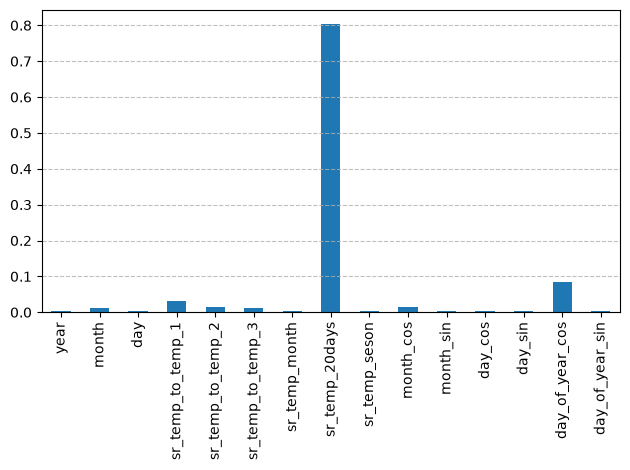

LinReg:
       year     month       day  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.004692  0.027246 -0.001704           0.666225            0.35526   

   sr_temp_to_temp_3  sr_temp_month  sr_temp_20days  sr_temp_seson  month_cos  \
0           0.385823      -0.231323        0.947311       0.036008  -0.344225   

   month_sin   day_cos   day_sin  day_of_year_cos  day_of_year_sin  
0   0.601287  0.100039  0.027506        -3.270457        -0.294956  
------------------------


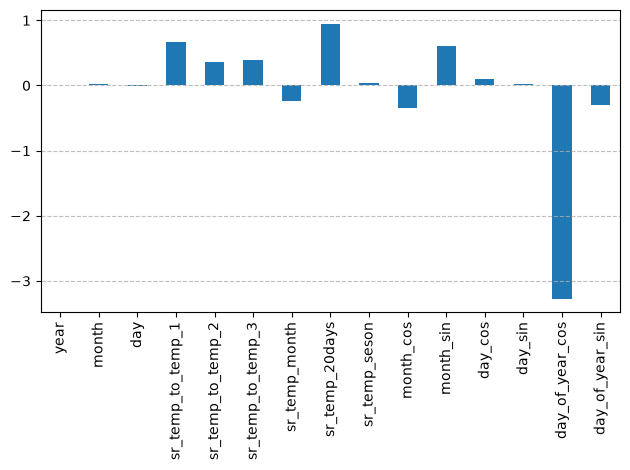

c:\Users\ivanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RForest:
       year     month       day  sr_temp_to_temp_1  sr_temp_to_temp_2  \
0  0.004044  0.010693  0.002605            0.00639           0.004764   

   sr_temp_to_temp_3  sr_temp_month  sr_temp_20days  sr_temp_seson  month_cos  \
0           0.004133        0.07656        0.096459       0.029889   0.031063   

   ...   day_cos  day_sin  day_of_year_cos  day_of_year_sin  Predicted  \
0  ...  0.002572  0.00273         0.062749         0.007799   0.168004   

   Predicted-temp  Predicted2  Predicted2-temp  Predicted_ras  Predicted_mean  
0        0.028777    0.205538         0.032628       0.004438        0.210775  

[1 rows x 21 columns]
------------------------


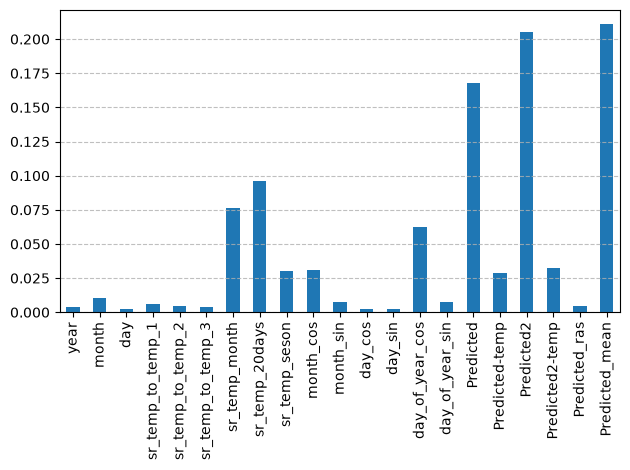

In [821]:
label_list = pd.DataFrame(df).columns.tolist()

label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_m2)]

x_train = df.iloc[:, label_number_list]
y_train = df.iloc[:, [3]]

model_Xboost = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5)
model_Xboost.fit(x_train, y_train)

label_list = pd.DataFrame(x_train).columns.tolist()

m = model_Xboost.feature_importances_
maxm = 0
name_max = 0
cof = pd.DataFrame()
for i in range(len(pd.DataFrame(x_train).columns.tolist())):
    cof[label_list[i]] = [m[i]]
    if m[i] > maxm:
        maxm = m[i]
        name_max = label_list[i]

print('XBoost:')
print(cof)
df_tail = df_naget.dropna()

print("------------------------")

coef_col_par = pd.DataFrame({
    "Параметр": [label_list],
    "коэффициент": [model_Xboost.feature_importances_]})

cof.iloc[0].plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

label_list = pd.DataFrame(df).columns.tolist()

label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_m2)]

x_train = df.iloc[:, label_number_list]
y_train = df.iloc[:, [3]]

model_LinReg = LinearRegression()
model_LinReg.fit(x_train, y_train)

label_list = pd.DataFrame(x_train).columns.tolist()

m = model_LinReg.coef_
maxm = 0
name_max = 0
cof = pd.DataFrame()
for i in range(len(pd.DataFrame(x_train).columns.tolist())):
    cof[label_list[i]] = [m[0][i]]
    if m[0][i] > maxm:
        maxm = m[0][i]
        name_max = label_list[i]

print('LinReg:')
print(cof)
df_tail = df_naget.dropna()

print("------------------------")

coef_col_par = pd.DataFrame({
    "Параметр": [label_list],
    "коэффициент": [model_LinReg.coef_]})

cof.iloc[0].plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

label_list = pd.DataFrame(df).columns.tolist()

label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_m1)]
x_train = df.iloc[:, label_number_list]
y_train = df.iloc[:, [3]]

model_RForest = RandomForestRegressor(max_depth=30, max_features=5)
model_RForest.fit(x_train,y_train)

label_list = pd.DataFrame(x_train).columns.tolist()

m = model_RForest.feature_importances_
maxm = 0
name_max = 0
cof = pd.DataFrame()
for i in range(len(pd.DataFrame(x_train).columns.tolist())):
    cof[label_list[i]] = [m[i]]
    if m[i] > maxm:
        maxm = m[i]
        name_max = label_list[i]

print('RForest:')
print(cof)
df_tail = df_naget.dropna()

print("------------------------")

coef_col_par = pd.DataFrame({
    "Параметр": [label_list],
    "коэффициент": [model_RForest.feature_importances_]})

cof.iloc[0].plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()
        

In [822]:
year = df['year'].iloc[-1]
last_20_days = df['sr_temp'].tail(20).values.tolist()
last_month = df['sr_temp'].tail(30).values.tolist()
last_season = df['sr_temp'].tail(70).values.tolist()
last_3_day = df['sr_temp'].tail(4).values.tolist()
last_temp = df['sr_temp'].tail(1).values.item()

df_new = pd.DataFrame(df.tail(1))
df_new = df_new.reset_index(drop=True)
year, month, day = date['year'], date['month'], date['day']
print(day)
print(month)
print(year)

df_new.head(-1)

17
6
2025


,year,month,day,sr_temp,sr_temp_to_temp_1,sr_temp_to_temp_2,sr_temp_to_temp_3,sr_temp_month,sr_temp_20days,sr_temp_seson,...,day_cos,day_sin,day_of_year_cos,day_of_year_sin,Predicted,Predicted-temp,Predicted2,Predicted2-temp,Predicted_ras,Predicted_mean


In [823]:
label_list = pd.DataFrame(df).columns.tolist()

for iter in range(1, predict_day_num+1):
    day += 1
                                                                                                                         
    if year == 400 or year % 4 == 0 and year % 100 != 0:         
        month_list_day = days_in_month_2   
        day_in_year = 366    
    else:                                                                       
        month_list_day = days_in_month_1
        day_in_year = 365

    if day > month_list_day[int(month)-1]:
        month += 1   
        day = 1     
    if month > 12:
        month = 1
        year += 1

    last_3_days_list = []
    for i in range(-1,-step-1,-1):
        last_3_days_list.append(round(float(last_3_day[i] - last_3_day[i-1]), 4)) 

    last_3_day = last_3_day[1:]
    last_3_day.append(last_temp)

    last_20_days = last_20_days[1:]
    last_20_days.append(last_temp)

    last_month = last_month[1:]
    last_month.append(last_temp)

    last_season = last_season[1:]
    last_season.append(last_temp)    

    def day_of_year(y, m, d):                                                                                                                                        
        if y % 400 == 0 or y % 4 == 0 and y % 100 != 0:         
            return sum(days_in_month_2[:int(m)-1]) + int(d)        
        else:                                                                       
            return sum(days_in_month_1[:int(m)-1]) + int(d)                                                                         

    day_of_year_n = day_of_year(year, month, day)

    def min_max(x, xmin, xmax):
        return (x - xmin) / (xmax - xmin)

    month_degree = min_max(month, 1, 12) * 2 * ma.pi   
    day_degree = min_max(day, 1, month_list_day[int(month)-1]) * 2 * ma.pi       
    day_of_year_n_degree = min_max(day_of_year_n, 1, day_in_year) * 2 * ma.pi    

    def set_rad_cos(x):
        return ma.cos(x)
    def set_rad_sin(x):
        return ma.sin(x)

    month_cos = set_rad_cos(month_degree)
    month_sin = set_rad_sin(month_degree)

    day_cos = set_rad_cos(day_degree)
    day_sin = set_rad_sin(day_degree)

    day_of_year_cos = set_rad_cos(day_of_year_n_degree)
    day_of_year_sin = set_rad_sin(day_of_year_n_degree)

    df_new.at[iter, 'year'] = year
    df_new.at[iter, 'month'] = month
    df_new.at[iter, 'day'] = day
    for i in range(step):
        df_new.at[iter, f'sr_temp_to_temp_{i+1}'] = last_3_days_list[i]
    df_new.at[iter, 'sr_temp_month'] = sum(last_month) / len(last_month)
    df_new.at[iter, 'sr_temp_20days'] = sum(last_20_days) / len(last_20_days)
    df_new.at[iter, 'sr_temp_seson'] = sum(last_season) / len(last_season)
    df_new.at[iter, 'month_cos'] = month_cos
    df_new.at[iter, 'month_sin'] = month_sin
    df_new.at[iter, 'day_cos'] = day_cos
    df_new.at[iter, 'day_sin'] = day_sin
    df_new.at[iter, 'day_of_year_cos'] = day_of_year_cos
    df_new.at[iter, 'day_of_year_sin'] = day_of_year_sin

    label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_m2)]
    x_train = df_new.iloc[[-1], label_number_list]
    predict_n = model_Xboost.predict(x_train)
    df_new.at[iter, 'Predicted'] = predict_n
    l = predict_n
    df_new.at[iter, 'Predicted-temp'] = predict_n - last_temp

    label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_m2)]
    x_train = df_new.iloc[[-1], label_number_list]
    predict_n = model_LinReg.predict(x_train)
    df_new.at[iter, 'Predicted2'] = predict_n[0]
    df_new.at[iter, 'Predicted2-temp'] = predict_n[0] - last_temp

    df_new.at[iter, 'Predicted_ras'] = l - predict_n[0]
    df_new.at[iter, 'Predicted_mean'] = (l + predict_n[0]) / 2

    label_number_list = [i for i in range(len(label_list)) if (i not in un_test_numbers_m1)]

    x_train = df_new.iloc[[-1], label_number_list]

    last_temp = model_RForest.predict(x_train)[0]

    df_new.at[iter, 'Predicted3'] = last_temp
    df_new.at[iter, 'sr_temp'] = last_temp

df_new.head(5)

,year,month,day,sr_temp,sr_temp_to_temp_1,sr_temp_to_temp_2,sr_temp_to_temp_3,sr_temp_month,sr_temp_20days,sr_temp_seson,...,day_sin,day_of_year_cos,day_of_year_sin,Predicted,Predicted-temp,Predicted2,Predicted2-temp,Predicted_ras,Predicted_mean,Predicted3
0,2025.0,6.0,17.0,16.700000,1.4000,1.0000,0.1,15.166667,16.000000,10.578571,...,-0.319302,-0.964614,0.263665,19.837299,0.837299,18.205594,-0.794406,1.631706,19.021447,NaN
1,2025.0,6.0,18.0,16.971143,-2.3000,1.4000,1.0,15.356667,15.860000,11.030000,...,-0.515554,-0.970942,0.239316,17.335798,0.635798,16.332846,-0.367154,1.002952,16.834322,16.971143
2,2025.0,6.0,19.0,17.169629,0.0000,-2.3000,1.4,15.479038,15.893557,11.291016,...,-0.687699,-0.974928,0.222521,17.208981,0.237838,16.742553,-0.228590,0.466428,16.975767,17.169629
3,2025.0,6.0,20.0,17.468217,0.2711,0.0000,-2.3,15.684692,16.007039,11.546297,...,-0.827689,-0.978624,0.205660,17.070278,-0.099350,16.409833,-0.759796,0.660445,16.740056,17.468217
4,2025.0,6.0,21.0,17.667500,0.1985,0.2711,0.0,15.836966,16.220449,11.814414,...,-0.928977,-0.982028,0.188738,18.404922,0.936706,17.552512,0.084295,0.852411,17.978717,17.667500


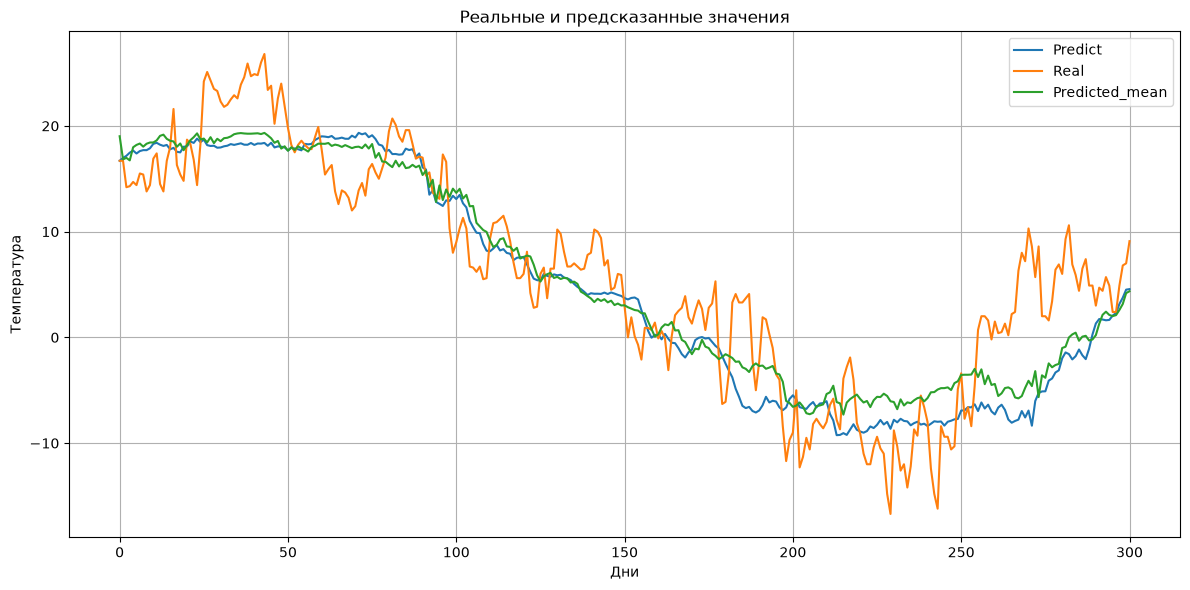

------------------------
# MAE и MSE по тестовой выборке
Test MSE:  24.076157814608408
Test MAE:  3.8028838912334284
------------------------
R^2: 0.7783107767372315


In [824]:
x_indexes = range(predict_day_num+1)
pred_vals = df_new['sr_temp']

plt.figure(figsize=(12, 6))
plt.plot(x_indexes, pred_vals, label='Predict')
try:
    plt.plot(x_indexes, df_after['sr_temp'], label='Real')
except:
    pass
plt.plot(x_indexes, df_new[name_max][-len(pred_vals):], label=name_max)
plt.xlabel('Дни')
plt.ylabel('Температура')
plt.title('Реальные и предсказанные значения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

try:
    print("------------------------")
    print("# MAE и MSE по тестовой выборке")
    print("Test MSE: ", mean_squared_error(pred_vals, df_after['sr_temp']))
    print("Test MAE: ", mean_absolute_error(pred_vals, df_after['sr_temp']))

    print("------------------------")
    r = r2_score(pred_vals, df_after['sr_temp'])
    p = len(label_list)
    print("R^2:", r)
except:
    pass